### LINK de acesso do código-fonte: 


https://github.com/carlosadauto7/metodos-matematicos-2026.1/blob/main/tarefa_04/tarefa_04.ipynb

### Questão 1

### Bloco 1: Importações e Definição da Sequência

Neste bloco, importamos as bibliotecas necessárias e definimos o termo geral da sequência $a(n)$ e o índice inicial $n_0$.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definição do índice inicial n0 e da função do termo geral a(n)
n0 = 1

def a(n):
    # Exemplo configurado: Série geométrica 1/(2^n)
    return 1 / (2**n)

### Bloco 2: Coleta das Entradas do Usuário

Aqui o programa implementa a lógica para as opções (a) e (b), coletando os parâmetros de convergência, tolerância e o intervalo de $k$.

In [7]:
# Escolha da opção exclusiva de execução
print("O usuário sabe que a série é convergente para uma soma S?")
print("(a) Sim")
print("(b) Não")
opcao = input("Escolha a opção (a ou b): ").strip().lower()

# Coleta de variáveis baseadas na escolha
if opcao == 'a':
    S = float(input("Digite o valor da soma S (ex: 1.0): "))
    epsilon = float(input("Digite o valor da tolerância epsilon (ex: 0.05): "))
else:
    S, epsilon = None, None

# Coleta dos limites kmin e kmax
kmin = int(input(f"Digite o valor de kmin (>= 0): "))
kmax = int(input(f"Digite o valor de kmax (> {kmin}, sugestão: diferença máx de 20): "))

O usuário sabe que a série é convergente para uma soma S?
(a) Sim
(b) Não


### Bloco 3: Processamento e Geração das Tabelas (Itens i e ii)

A soma parcial $S(k)$ é calculada desde $k=0$ para garantir a acumulação correta, mas as tabelas armazenarão apenas os valores no intervalo de $[k_{min}, k_{max}]$.

In [8]:
k_vals = []
a_vals = []
S_vals = []

soma_atual = 0

# Iteramos de 0 até kmax para acumular a soma corretamente desde n0
for k in range(0, kmax + 1):
    n_atual = n0 + k
    termo = a(n_atual)
    soma_atual += termo
    
    # Armazenamos apenas os pares dentro do intervalo solicitado
    if k >= kmin:
        k_vals.append(k)
        a_vals.append(termo)
        S_vals.append(soma_atual)

# Estruturação dos dados usando Pandas
df = pd.DataFrame({
    'k': k_vals,
    'a(k)': a_vals,
    'S(k)': S_vals
})

# Saídas (i) e (ii): Impressão das tabelas
print("\n--- (i) Tabela de pares (k, a(k)) ---")
print(df[['k', 'a(k)']].to_string(index=False))

print("\n--- (ii) Tabela de pares (k, S(k)) ---")
print(df[['k', 'S(k)']].to_string(index=False))


--- (i) Tabela de pares (k, a(k)) ---
  k         a(k)
  0 5.000000e-01
  1 2.500000e-01
  2 1.250000e-01
  3 6.250000e-02
  4 3.125000e-02
  5 1.562500e-02
  6 7.812500e-03
  7 3.906250e-03
  8 1.953125e-03
  9 9.765625e-04
 10 4.882812e-04
 11 2.441406e-04
 12 1.220703e-04
 13 6.103516e-05
 14 3.051758e-05
 15 1.525879e-05
 16 7.629395e-06
 17 3.814697e-06
 18 1.907349e-06
 19 9.536743e-07
 20 4.768372e-07
 21 2.384186e-07
 22 1.192093e-07
 23 5.960464e-08
 24 2.980232e-08
 25 1.490116e-08
 26 7.450581e-09
 27 3.725290e-09
 28 1.862645e-09
 29 9.313226e-10
 30 4.656613e-10
 31 2.328306e-10
 32 1.164153e-10
 33 5.820766e-11
 34 2.910383e-11
 35 1.455192e-11
 36 7.275958e-12
 37 3.637979e-12
 38 1.818989e-12
 39 9.094947e-13
 40 4.547474e-13
 41 2.273737e-13
 42 1.136868e-13
 43 5.684342e-14
 44 2.842171e-14
 45 1.421085e-14
 46 7.105427e-15
 47 3.552714e-15
 48 1.776357e-15
 49 8.881784e-16
 50 4.440892e-16
 51 2.220446e-16
 52 1.110223e-16
 53 5.551115e-17
 54 2.775558e-17
 55 1.387

### Bloco 4: Plotagem do Gráfico (Itens iii e iv)

Este bloco gera a visualização discreta dos pontos. Se a opção (a) tiver sido escolhida, ele adiciona as linhas horizontais de limite e verifica automaticamente se a condição de ter "pelo menos a metade dos pares na faixa" foi atingida.

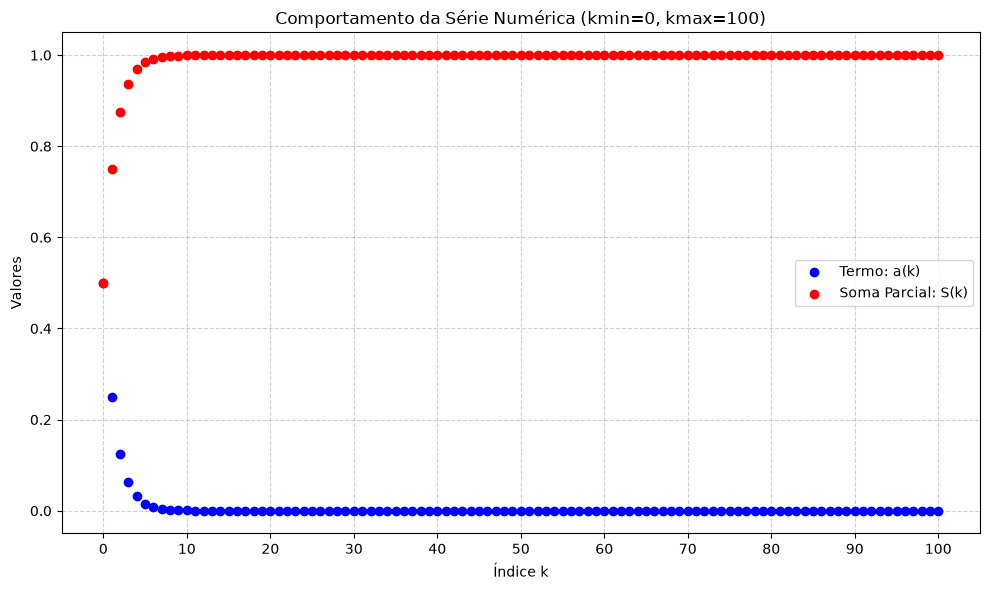

In [9]:
plt.figure(figsize=(10, 6))

# (iii) Gráfico mostrando os conjuntos de pontos em cores distintas de maneira discreta
plt.scatter(df['k'], df['a(k)'], color='blue', label='Termo: a(k)', zorder=5)
plt.scatter(df['k'], df['S(k)'], color='red', label='Soma Parcial: S(k)', zorder=5)

# (iv) Adição das retas horizontais caso a opção seja (a)
if opcao == 'a':
    plt.hlines(y=S, xmin=kmin, xmax=kmax, colors='green', linestyles='solid', label='Soma S')
    plt.hlines(y=S - epsilon, xmin=kmin, xmax=kmax, colors='orange', linestyles='dashed', label='S - ε')
    plt.hlines(y=S + epsilon, xmin=kmin, xmax=kmax, colors='orange', linestyles='dashed', label='S + ε')
    
    # Verificação auxiliar: checar se metade dos pontos S(k) estão na faixa [S-ε, S+ε]
    pontos_na_faixa = sum((S - epsilon) <= val <= (S + epsilon) for val in S_vals)
    if pontos_na_faixa < len(S_vals) / 2:
        print(f"\nAVISO: Apenas {pontos_na_faixa} de {len(S_vals)} pontos estão na faixa [S - ε, S + ε].")
        print("Ajuste os valores de kmin, kmax ou epsilon na próxima execução para atender ao critério do item (iv).")

# Configurações visuais do gráfico
plt.title(f"Comportamento da Série Numérica (kmin={kmin}, kmax={kmax})")
plt.xlabel("Índice k")
plt.ylabel("Valores")
plt.xticks(np.arange(kmin, kmax + 1, step=max(1, (kmax - kmin) // 10)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Exibição da figura
plt.show()

### Questão 2(a)

In [ ]:
n0 = 1

def a(n):
    return 1 / n

In [12]:
# Coleta das entradas
print("O usuário sabe que a série é convergente para uma soma S?")
print("(a) Sim")
print("(b) Não")
opcao = input("Escolha a opção (a ou b): ").strip().lower()

if opcao == 'a':
    S = float(input("Digite o valor da soma S (ex: 1.0): "))
    epsilon = float(input("Digite o valor da tolerância epsilon (ex: 0.05): "))
else:
    S, epsilon = None, None

kmin = int(input(f"Digite o valor de kmin (>= 0): "))
kmax = int(input(f"Digite o valor de kmax (> {kmin}): "))

O usuário sabe que a série é convergente para uma soma S?
(a) Sim
(b) Não


In [13]:
k_vals = []
a_vals = []
S_vals = []
soma_atual = 0

# Processamento
for k in range(0, kmax + 1):
    n_atual = n0 + k
    termo = a(n_atual)
    soma_atual += termo
    
    if k >= kmin:
        k_vals.append(k)
        a_vals.append(termo)
        S_vals.append(soma_atual)

# Criação do DataFrame
df = pd.DataFrame({'k': k_vals, 'a(k)': a_vals, 'S(k)': S_vals})

In [14]:
# Saídas (i) e (ii) renderizadas para Jupyter Notebook
print("--- (i) Tabela de pares (k, a(k)) ---")
display(df[['k', 'a(k)']])

print("\n--- (ii) Tabela de pares (k, S(k)) ---")
display(df[['k', 'S(k)']])

--- (i) Tabela de pares (k, a(k)) ---


,k,a(k)
0,0,1.000000
1,1,0.500000
2,2,0.333333
3,3,0.250000
4,4,0.200000
5,5,0.166667
6,6,0.142857
7,7,0.125000
8,8,0.111111
9,9,0.100000



--- (ii) Tabela de pares (k, S(k)) ---


,k,S(k)
0,0,1.000000
1,1,1.500000
2,2,1.833333
3,3,2.083333
4,4,2.283333
5,5,2.450000
6,6,2.592857
7,7,2.717857
8,8,2.828968
9,9,2.928968


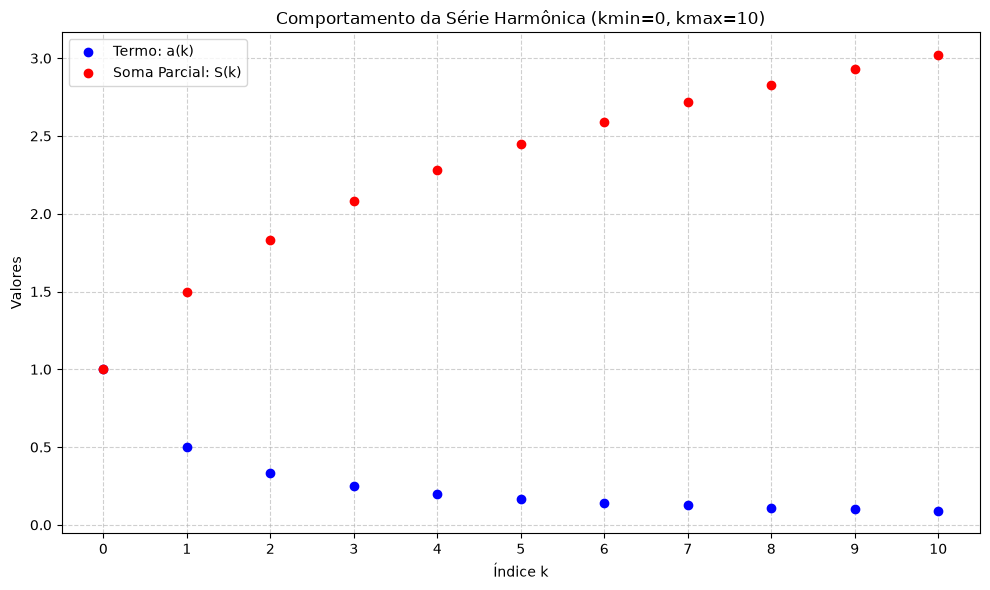

In [15]:
# Saídas (iii) e (iv) na interface gráfica
plt.figure(figsize=(10, 6))
plt.scatter(df['k'], df['a(k)'], color='blue', label='Termo: a(k)', zorder=5)
plt.scatter(df['k'], df['S(k)'], color='red', label='Soma Parcial: S(k)', zorder=5)

if opcao == 'a':
    plt.hlines(y=S, xmin=kmin, xmax=kmax, colors='green', linestyles='solid', label='Soma S')
    plt.hlines(y=S - epsilon, xmin=kmin, xmax=kmax, colors='orange', linestyles='dashed', label='S - ε')
    plt.hlines(y=S + epsilon, xmin=kmin, xmax=kmax, colors='orange', linestyles='dashed', label='S + ε')

plt.title(f"Comportamento da Série Harmônica (kmin={kmin}, kmax={kmax})")
plt.xlabel("Índice k")
plt.ylabel("Valores")
plt.xticks(np.arange(kmin, kmax + 1, step=max(1, (kmax - kmin) // 10)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Questão 4(c)

In [9]:
import numpy as np

# n0 = 1
def a(n):
    # Expressão original da série
    return 1 / (np.sqrt(n+1) * np.sqrt(n) * (np.sqrt(n+1) + np.sqrt(n)))

In [3]:
# Coleta das entradas
print("O usuário sabe que a série é convergente para uma soma S?")
print("(a) Sim")
print("(b) Não")
opcao = input("Escolha a opção (a ou b): ").strip().lower()

if opcao == 'a':
    S = float(input("Digite o valor da soma S (ex: 1.0): "))
    epsilon = float(input("Digite o valor da tolerância epsilon (ex: 0.05): "))
else:
    S, epsilon = None, None

kmin = int(input(f"Digite o valor de kmin (>= 0): "))
kmax = int(input(f"Digite o valor de kmax (> {kmin}): "))

O usuário sabe que a série é convergente para uma soma S?
(a) Sim
(b) Não


In [10]:
k_vals = []
a_vals = []
S_vals = []
soma_atual = 0
n0 = 1

# Processamento
for k in range(0, kmax + 1):
    n_atual = n0 + k
    termo = a(n_atual)
    soma_atual += termo
    
    if k >= kmin:
        k_vals.append(k)
        a_vals.append(termo)
        S_vals.append(soma_atual)

# Criação do DataFrame
df = pd.DataFrame({'k': k_vals, 'a(k)': a_vals, 'S(k)': S_vals})

In [11]:
# Saídas (i) e (ii) renderizadas para Jupyter Notebook
print("--- (i) Tabela de pares (k, a(k)) ---")
display(df[['k', 'a(k)']])

print("\n--- (ii) Tabela de pares (k, S(k)) ---")
display(df[['k', 'S(k)']])

--- (i) Tabela de pares (k, a(k)) ---


,k,a(k)
0,999990,5.000064e-10
1,999991,5.000056e-10
2,999992,5.000049e-10
3,999993,5.000041e-10
4,999994,5.000034e-10
5,999995,5.000026e-10
6,999996,5.000019e-10
7,999997,5.000011e-10
8,999998,5.000004e-10
9,999999,4.999996e-10



--- (ii) Tabela de pares (k, S(k)) ---


,k,S(k)
0,999990,0.999
1,999991,0.999
2,999992,0.999
3,999993,0.999
4,999994,0.999
5,999995,0.999
6,999996,0.999
7,999997,0.999
8,999998,0.999
9,999999,0.999


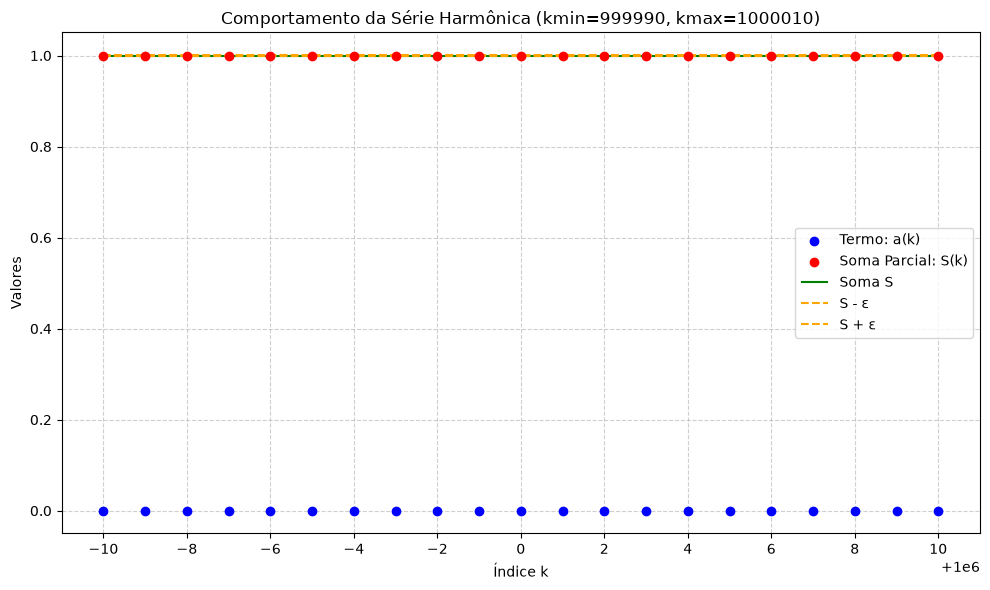

In [12]:
# Saídas (iii) e (iv) na interface gráfica
plt.figure(figsize=(10, 6))
plt.scatter(df['k'], df['a(k)'], color='blue', label='Termo: a(k)', zorder=5)
plt.scatter(df['k'], df['S(k)'], color='red', label='Soma Parcial: S(k)', zorder=5)

if opcao == 'a':
    plt.hlines(y=S, xmin=kmin, xmax=kmax, colors='green', linestyles='solid', label='Soma S')
    plt.hlines(y=S - epsilon, xmin=kmin, xmax=kmax, colors='orange', linestyles='dashed', label='S - ε')
    plt.hlines(y=S + epsilon, xmin=kmin, xmax=kmax, colors='orange', linestyles='dashed', label='S + ε')

plt.title(f"Comportamento da Série Harmônica (kmin={kmin}, kmax={kmax})")
plt.xlabel("Índice k")
plt.ylabel("Valores")
plt.xticks(np.arange(kmin, kmax + 1, step=max(1, (kmax - kmin) // 10)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()